**Building a Simple Neural Network**

This is the first lab of course PyTorch for Deep Learning

**Goal**


*   Build and train first neural network with a single neuron that learn patterns from data to make predictions.

****

**Scenario:**
You're a bike delivery person with a 7-mile delivery order. Your company promises delivery in under 30 minutes, and one more late delivery would put your job at risk.
*****
We will:
- Prepare delivery data, the distance and time from past orders
- Build a simple neural network using PyTorch (just 1 neuron)
- Train it to find the relationship between distance and delivery time
- Predict whether you can make that 7-mile delivery in time





# **Imports**



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import helper_utils


#This line ensures that your results are reproducible and consistent everyime.
torch.manual_seed(42)

*Try to understand the role of manual_seed by the code below*

In [2]:
import torch

print("Without manual seed:")
print(torch.rand(1))
print(torch.rand(1))

print("\nHas manual seed = 42:")
torch.manual_seed(42)
print(torch.rand(1))

print("\nreset manual seed with same value = 42:")
torch.manual_seed(42)
print(torch.rand(1))

print("\nreset manual seed with different value = 64:")
torch.manual_seed(64)
print(torch.rand(1))


Without manual seed:
tensor([0.8823])
tensor([0.9150])

Has manual seed = 42:
tensor([0.8823])

reset manual seed with same value = 42:
tensor([0.8823])

reset manual seed with different value = 64:
tensor([0.0492])


#The Machine Learning Pipeline in Action

##Stage 1&2: Data Ingestion and Preparation

* Define the two essential tensors for the task:
  *  the distance tensor contains how far you biked for 4 recent deliveries (in miles)
  * the times tensor shows how long the delivery took (in minutes)
  * dtype=torch.float32 sets your data type to 32-bit floating point values for precise calculations


In [3]:
#Distance in miles for recent bike deliveries
distances = torch.tensor([[1.0],[2.0],[3.0],[4.0]], dtype=torch.float32)

#Corresponding delivery times in minutes
times = torch.tensor([[6.96],[12.11],[16.77],[22.22]], dtype=torch.float32)

# Stage 3: Model Building

For bike deliveries,you'll assume a linear relationship between distance and time, a reasonable starting point. Your model will be a single neuron that learns this relationship.

A linear equation: Time = W x Distance + B

The model job is to find the best values for the weight (W) and bias (B) that fit the deliveries data.

We'll use nn.Sequential(nn.Linear(1,1)) to create linear model
* nn.Linear(1,1): the first 1 means that it take 1 input (distance), and the 2nd 1 means 1 neuron that is producing 1 output (predicted time)
* nn.Sequential: help us to add layer to neuron network following an other. In this example we have only 1 layer, the linear layer so we don't see much of it yet.

In [4]:
#Create a model with 1 input (distance) and one output (time)
model = nn.Sequential(nn.Linear(1,1))


# Stage 4: Training

Time to train the neural network. In this case 1 model of 1 linear layer of 1 neuron 😼

We will need two key tools to help the model learn from the data
* **Loss Function**: nn.MSELoss which is Mean Squared Error loss function. It measures how wrong the prediction are. The model has a goal to minimise the loss.
* **Optimizer**: optim.SD sets up the Stochastic Gradient Descent optimizer. It adjusts the weight and bias parameters based on the loss. lr = 0.01 is the *learning rate* which defines how big each adjustment step is.  

In [5]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

Now it's time for the model to learn. The training loop is where the model cycles through the data repeatedly, gradually discovering the relationship between distance and delivery time.

We'll train for 500 epochs (an epoch = a complete pass through the data). During each epoch, these following things occur:



1.   `optimizer.zero_grad()`: Clears gradients from previous round. Without this, PyTorch would accumulate adjustments, which could break the learning process.
2.   `outputs = model(distances)`: Perform the "forward pass", where the model makes predictions based on the input distances.
3.   `loss = loss_function(outputs, times)`: Calculates how wrong the predicted outputs are by comparing them to actual delivery times.
4.   `loss.backward()`: The "backward pass" (backpropagation) is performed, which calculates exactly how to adjust the weight and bias to reduce the error
5.   `optimizer.step()`: Update the model's parameters using those calculated adjustment in step 4.
6.   the `loss` is printed every 50 epocs to allow tracking the model's learning progress and the error decrease.  



In [6]:
# Training loop
for epoch in range (500):
  # Reset the optimizer's gradient
  optimizer.zero_grad()

  # Make predictions (forward pass)
  outputs = model(distances)

  # Calculate the loss
  loss = loss_function(outputs, times)

  # Calculate the adjustment by backward propagation (backward pass)
  loss.backward()

  # Update the model parameter
  optimizer.step()

  # Print loss every 50 epochs
  if (epoch +1) % 50 ==0:
    print(f"Epoch {epoch + 1}: Loss = {loss.item()}")

Epoch 50: Loss = 0.10756294429302216
Epoch 100: Loss = 0.0864570289850235
Epoch 150: Loss = 0.07082214206457138
Epoch 200: Loss = 0.05923750251531601
Epoch 250: Loss = 0.05065387487411499
Epoch 300: Loss = 0.044294361025094986
Epoch 350: Loss = 0.039582230150699615
Epoch 400: Loss = 0.03609074279665947
Epoch 450: Loss = 0.03350376710295677
Epoch 500: Loss = 0.03158711642026901


# Visualising the Training Result

After trained, we can plot the model predictions as a line againts actual delivery data (distance, time)


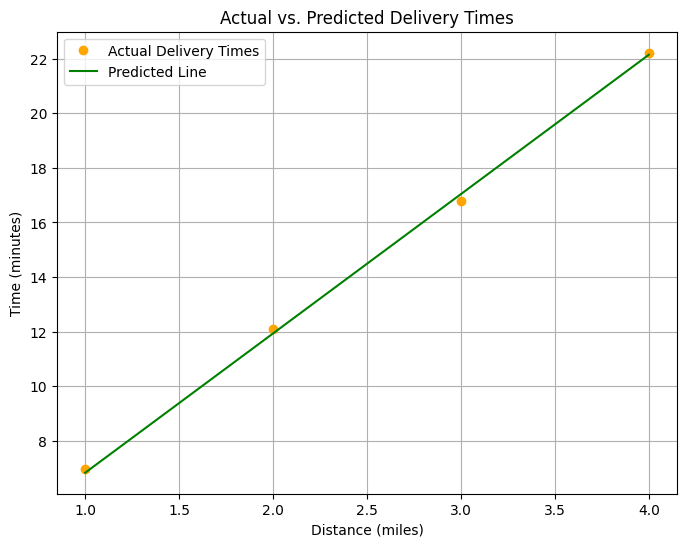

In [7]:
helper_utils.plot_results(model, distances, times)

# Make The Prediction
Now model is trained. Can it answer question: can we make the appointment 7-mile delivery in under 30 minutes?

In [9]:
distance_to_predict = 7.0


In [11]:
with torch.no_grad():
  # Convert the variable to the 2D PyTorch tensor that model expects
  new_distance = torch.tensor([[distance_to_predict]], dtype=torch.float32)

  # Pass the new data to the trained model to get a prediction
  predicted_time = model(new_distance)

  # Use .item() to extract the scalar value from the tensor for printing
  print(f"Prediction for a {distance_to_predict}-mile delivery: {predicted_time.item():.1f} minutes")

  # Use the scalar value in a conditional statement to make the final decision
  if predicted_time.item() > 30:
    print("\nDecision: Do NOT take the job. You will likely be late.")
  else:
    print("\nDecision: Take the job. You can make it!")


Prediction for a 7.0-mile delivery: 37.5 minutes

Decision: Do NOT take the job. You will likely be late.


# Inspecting the Model learning

In [12]:
# Access the first (and only) layer in the sequential model
layer = model[0]

# Get weights and bias
weights = layer.weight.data.numpy()
bias = layer.bias.data.numpy()

print(f"Weight: {weights}")
print(f"Bias: {bias}")

Weight: [[5.1054373]]
Bias: [1.7243671]


# Testing the model on more complex data

In [14]:
# Combined dataset: bikes for short distances, cars for longer ones
new_distances = torch.tensor([
    [1.0], [1.5], [2.0], [2.5], [3.0], [3.5], [4.0], [4.5], [5.0], [5.5],
    [6.0], [6.5], [7.0], [7.5], [8.0], [8.5], [9.0], [9.5], [10.0], [10.5],
    [11.0], [11.5], [12.0], [12.5], [13.0], [13.5], [14.0], [14.5], [15.0], [15.5],
    [16.0], [16.5], [17.0], [17.5], [18.0], [18.5], [19.0], [19.5], [20.0]
], dtype=torch.float32)

# Corresponding delivery times in minutes
new_times = torch.tensor([
    [6.96], [9.67], [12.11], [14.56], [16.77], [21.7], [26.52], [32.47], [37.15], [42.35],
    [46.1], [52.98], [57.76], [61.29], [66.15], [67.63], [69.45], [71.57], [72.8], [73.88],
    [76.34], [76.38], [78.34], [80.07], [81.86], [84.45], [83.98], [86.55], [88.33], [86.83],
    [89.24], [88.11], [88.16], [91.77], [92.27], [92.13], [90.73], [90.39], [92.98]
], dtype=torch.float32)

Now let's see how well the model handles this new mixed dataset
- we will use the trained model to predict the times for new distances

In [15]:
# Use the already trained linear model to make predictions
with torch.no_grad():
  predicted_times = model(new_distances)

- Calculate `new_loss`bewteen model's prediction and actual times
- Notice how the loss value will be significantly higher than the loss at the end of the training. This will indicate a poor fit.

In [17]:
# Calculate the new_loss
new_loss = loss_function(predicted_times, new_times)

# Print the new_loss
print(f"New Loss: {new_loss.item()}")

New Loss: 169.36282348632812


*Plot the model and the data to see the differences*


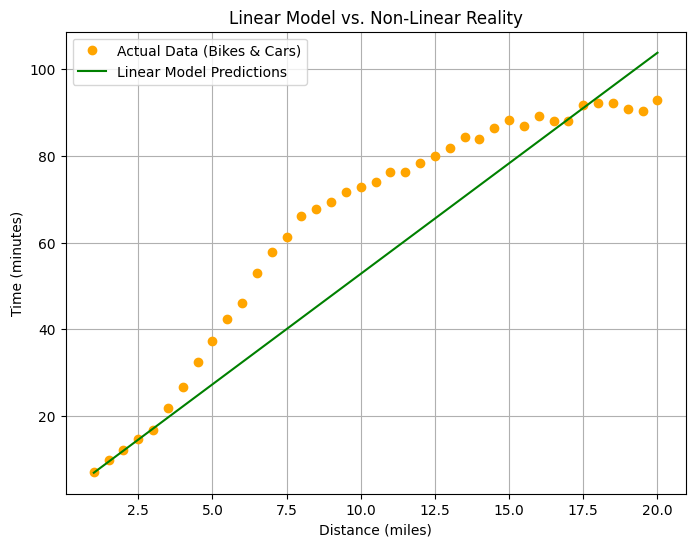

In [18]:
helper_utils.plot_nonlinear_comparison(model, new_distances, new_times)

In [19]:
import os
print(os.getcwd())


/content


In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git init

This command creates a new, empty Git repository in the current directory, which is typically `/content/` in Colab unless you've changed it or mounted Google Drive.